# DeepLOB: FI-2010 → LOBS5 Fine-Tune → LOBSTER Zero-Shot

**Goal.** Take the DeepLOB checkpoints already trained on FI-2010 (Setup 2) for horizons k ∈ {10, 20, 50}, fine-tune each one on **synthetic LOBS5 data** (peernagy/lob_bench, GOOG + INTC, `data_gen_lobs5` only) under two regimes — full SFT and rank-8 LoRA — and benchmark the result on **LOBSTER** using the same 30% test slice as the zero-shot benchmark.

The hypothesis: synthetic LOB data with realistic micro-structure should reduce the FI-2010 → LOBSTER covariate gap without needing real LOBSTER labels at fine-tune time.

**Pipeline per horizon k:**
1. Load `DeepLOB_k{k}.pt` from Drive.
2. Fine-tune (a) full SFT and (b) LoRA-r8 on LOBS5 (val-best checkpointed each epoch).
3. Evaluate all three models — zero-shot baseline, SFT, LoRA — on the LOBSTER 30% test slice.

**Outputs to Drive (`lob_checkpoints/`):**
- `DeepLOB_k{k}_sft_lobs5.pt`
- `DeepLOB_k{k}_lora_lobs5.pt`

**Runtime on T4:** LOBS5 reconstruction is cached to Drive so re-runs skip it.


## 1. Setup

In [1]:
!pip install -q huggingface_hub

import os
import bisect
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from huggingface_hub import hf_hub_download, list_repo_files
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, confusion_matrix,
    precision_recall_fscore_support, cohen_kappa_score, classification_report
)
from tqdm.auto import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
GLOBAL_SEED = 42

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(GLOBAL_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}  |  '
          f'mem: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device: cuda
GPU: Tesla T4  |  mem: 15.6 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive/')

# ── Paths ────────────────────────────────────────────────────────────────────
DRIVE_ROOT     = Path('/content/drive/MyDrive/colab_data')
DRIVE_CKPT_DIR = DRIVE_ROOT / 'lob_checkpoints'
DRIVE_LOBS5_CACHE = DRIVE_ROOT / 'lobs5_cache'
DRIVE_RESULTS_DIR = DRIVE_ROOT / 'lobs5_finetune_results'

LOCAL_CKPT_DIR = Path('./checkpoints')
LOCAL_LOBS5_DIR = Path('./lobs5_data')
LOCAL_RESULTS_DIR = Path('./results')

for d in [DRIVE_CKPT_DIR, DRIVE_LOBS5_CACHE, DRIVE_RESULTS_DIR,
          LOCAL_CKPT_DIR, LOCAL_LOBS5_DIR, LOCAL_RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Drive checkpoint dir : {DRIVE_CKPT_DIR}')
print(f'Drive LOBS5 cache    : {DRIVE_LOBS5_CACHE}')
print(f'Drive results dir    : {DRIVE_RESULTS_DIR}')


Mounted at /content/drive/
Drive checkpoint dir : /content/drive/MyDrive/colab_data/lob_checkpoints
Drive LOBS5 cache    : /content/drive/MyDrive/colab_data/lobs5_cache
Drive results dir    : /content/drive/MyDrive/colab_data/lobs5_finetune_results


In [3]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
T          = 100
HORIZONS   = [10, 20, 50]
N_CLASSES  = 3
LABEL_NAMES = ['Down', 'Stat', 'Up']

# LOBS5 source
LOBS5_REPO       = 'peernagy/lob_bench'
LOBS5_TICKERS    = ['GOOG', 'INTC']
LOBS5_RUN_DIR    = 'data_gen_lobs5'
N_LEVELS_LOBS5   = 10
MAX_FILES_PER_TICKER = None    # ~1M events / ticker — bump up for more data
WARMUP_EVENTS    = 0          # events to drop from the start of each segment
ALPHA_THRESHOLD  = 1e-5       # mid-price label threshold (matches benchmarking nb)
LOBS5_VAL_FRAC   = 0.10       # fraction of segments held out for validation

# LOBSTER (target) — match benchmarking notebook exactly
HF_LOBSTER_REPO    = 'totalorganfailure/lobster-data'
LOBSTER_TICKERS    = ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
LOBSTER_LEVELS     = 10
LOBSTER_DATE       = '2012-06-21'
LOBSTER_START      = '34200000'
LOBSTER_END        = '57600000'
LOBSTER_TRAIN_FRAC = 0.7      # we discard the 70%, eval on the 30% held out

# Fine-tune config
FT_BATCH_SIZE   = 64
FT_EVAL_BATCH   = 512
SFT_LR          = 1e-4
SFT_WD          = 1e-5
LORA_LR         = 5e-4
LORA_WD         = 0.0
FT_EPOCHS       = 15
FT_PATIENCE     = 4

# LoRA config
LORA_R       = 8
LORA_ALPHA   = 16.0


## 2. DeepLOB Architecture

Verbatim copy of the architecture used in the benchmarking notebook.

In [4]:
class InceptionModule(nn.Module):
    """Inception module — Figure 4 of Zhang et al. (2019)."""
    def __init__(self, in_channels: int, n_filters: int = 32):
        super().__init__()
        self.b1_1x1  = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')
        self.b1_3x1  = nn.Conv2d(n_filters,   n_filters, kernel_size=(3, 1), padding='same')
        self.b2_1x1  = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')
        self.b2_5x1  = nn.Conv2d(n_filters,   n_filters, kernel_size=(5, 1), padding='same')
        self.b3_pool = nn.MaxPool2d(kernel_size=(3, 1), stride=1, padding=(1, 0))
        self.b3_1x1  = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')
        self.bn      = nn.BatchNorm2d(n_filters * 3)
        self.act     = nn.LeakyReLU(0.01)

    def forward(self, x):
        b1 = self.act(self.b1_3x1(self.act(self.b1_1x1(x))))
        b2 = self.act(self.b2_5x1(self.act(self.b2_1x1(x))))
        b3 = self.act(self.b3_1x1(self.b3_pool(x)))
        return self.act(self.bn(torch.cat([b1, b2, b3], dim=1)))


class DeepLOB(nn.Module):
    def __init__(self, T: int = 100, n_classes: int = 3):
        super().__init__()
        self.conv1a = nn.Conv2d(1,  16, kernel_size=(1, 2), stride=(1, 2))
        self.conv1b = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        self.conv1c = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        self.conv2a = nn.Conv2d(16, 16, kernel_size=(1, 2), stride=(1, 2))
        self.conv2b = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        self.conv2c = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        self.conv3a     = nn.Conv2d(16, 16, kernel_size=(1, 10))
        self.conv3b     = nn.Conv2d(16, 16, kernel_size=(4, 1), padding=(2, 0))
        self.conv3c     = nn.Conv2d(16, 16, kernel_size=(4, 1), padding=(2, 0))
        self.bn_spatial = nn.BatchNorm2d(16)
        self.inception  = InceptionModule(in_channels=16, n_filters=32)
        self.lstm       = nn.LSTM(input_size=96, hidden_size=64, batch_first=True)
        self.classifier = nn.Linear(64, n_classes)
        self.act        = nn.LeakyReLU(0.01)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, p in m.named_parameters():
                    if 'weight' in name: nn.init.orthogonal_(p)
                    elif 'bias'  in name: nn.init.zeros_(p)

    def forward(self, x):
        x = x.unsqueeze(1)                      # (B, 1, T, 40)
        x = self.act(self.conv1a(x))
        x = self.act(self.conv1b(x))
        x = self.act(self.conv1c(x))
        x = self.act(self.conv2a(x))
        x = self.act(self.conv2b(x))
        x = self.act(self.conv2c(x))
        x = self.act(self.conv3a(x))
        x = self.act(self.conv3b(x))
        x = self.act(self.bn_spatial(self.conv3c(x)))
        x = self.inception(x)                   # (B, 96, T, 1)
        x = x.squeeze(-1).permute(0, 2, 1)      # (B, T, 96)
        _, (h, _) = self.lstm(x)
        return self.classifier(h.squeeze(0))    # (B, 3)


# Sanity
_m = DeepLOB(T=T).to(DEVICE)
_d = torch.randn(4, T, 40).to(DEVICE)
print(f'Output : {_m(_d).shape}')
print(f'Params : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _d


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


Output : torch.Size([4, 3])
Params : 61,171


## 3. LoRA Adapters

`nn.LSTM` doesn't expose its forward computation in a way that lets us inject low-rank deltas while keeping cuDNN's fused kernel. We could fight `nn.utils.parametrize`, but the simplest, most reliable approach is a custom wrapper that runs the LSTM cell loop in Python with effective weights `W_ih + ΔW_ih` and `W_hh + ΔW_hh` where `ΔW = (α/r) · B·A`. The frozen base weights still live on the wrapped `nn.LSTM`, so they can be loaded directly from the FI-2010 checkpoint.

Targets (per the design):
- `lstm.weight_ih_l0` → LoRA on the input-to-hidden gate projection (4·H × in)
- `lstm.weight_hh_l0` → LoRA on the hidden-to-hidden gate projection (4·H × H)
- `classifier.weight` → LoRA on the final 64 → 3 classifier head

Conv + Inception + BatchNorm stay frozen. With r=8, trainable param count is small (printed below).


In [5]:
class LoRALSTM(nn.Module):
    """
    LoRA-wrapped single-layer batch-first nn.LSTM. Runs the cell loop in Python so
    the LoRA deltas can be added to the gate projections without going through cuDNN.

    Output matches nn.LSTM: (output, (h_n, c_n)) with h_n/c_n shape (1, B, H).
    """
    def __init__(self, base_lstm: nn.LSTM, r: int = 8, alpha: float = 16.0):
        super().__init__()
        assert base_lstm.num_layers == 1 and base_lstm.batch_first and not base_lstm.bidirectional

        self.input_size  = base_lstm.input_size
        self.hidden_size = base_lstm.hidden_size

        # Frozen base weights (kept inside this module so state_dict round-trips)
        self.weight_ih = nn.Parameter(base_lstm.weight_ih_l0.detach().clone(), requires_grad=False)
        self.weight_hh = nn.Parameter(base_lstm.weight_hh_l0.detach().clone(), requires_grad=False)
        self.bias_ih   = nn.Parameter(base_lstm.bias_ih_l0.detach().clone(),   requires_grad=False)
        self.bias_hh   = nn.Parameter(base_lstm.bias_hh_l0.detach().clone(),   requires_grad=False)

        # LoRA adapters — A ~ N(0, 0.01²), B = 0  →  initial Δ = 0
        H = self.hidden_size
        self.lora_A_ih = nn.Parameter(torch.randn(r, self.input_size)  * 0.01)
        self.lora_B_ih = nn.Parameter(torch.zeros(4 * H, r))
        self.lora_A_hh = nn.Parameter(torch.randn(r, H)                * 0.01)
        self.lora_B_hh = nn.Parameter(torch.zeros(4 * H, r))
        self.r       = r
        self.scaling = alpha / r

    def forward(self, x, initial_state=None):
        B, Tlen, _ = x.shape
        H = self.hidden_size

        W_ih = self.weight_ih + self.scaling * (self.lora_B_ih @ self.lora_A_ih)
        W_hh = self.weight_hh + self.scaling * (self.lora_B_hh @ self.lora_A_hh)
        b    = self.bias_ih + self.bias_hh

        # Precompute input projection for ALL timesteps in one batched matmul.
        # This converts T small (B, in)x(in, 4H) matmuls into one (B, T, in)x(in, 4H),
        # which is 5–10× faster on GPU than the naive per-step loop.
        x_proj = x @ W_ih.t()                       # (B, T, 4H)
        Wh_t   = W_hh.t()

        if initial_state is None:
            h = x.new_zeros(B, H); c = x.new_zeros(B, H)
        else:
            h, c = initial_state
            h = h.squeeze(0); c = c.squeeze(0)

        outputs = []
        for t in range(Tlen):
            gates = x_proj[:, t, :] + h @ Wh_t + b
            i_g, f_g, g_g, o_g = gates.chunk(4, dim=1)
            i_g = torch.sigmoid(i_g); f_g = torch.sigmoid(f_g)
            g_g = torch.tanh(g_g);    o_g = torch.sigmoid(o_g)
            c = f_g * c + i_g * g_g
            h = o_g * torch.tanh(c)
            outputs.append(h)

        out = torch.stack(outputs, dim=1)            # (B, T, H)
        return out, (h.unsqueeze(0), c.unsqueeze(0))


class LoRALinear(nn.Module):
    """LoRA-wrapped nn.Linear. Frozen base weight, low-rank trainable delta."""
    def __init__(self, base_linear: nn.Linear, r: int = 8, alpha: float = 16.0):
        super().__init__()
        self.in_features  = base_linear.in_features
        self.out_features = base_linear.out_features
        self.weight = nn.Parameter(base_linear.weight.detach().clone(), requires_grad=False)
        self.bias   = (nn.Parameter(base_linear.bias.detach().clone(),  requires_grad=False)
                       if base_linear.bias is not None else None)
        self.lora_A = nn.Parameter(torch.randn(r, self.in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(self.out_features, r))
        self.r       = r
        self.scaling = alpha / r

    def forward(self, x):
        W = self.weight + self.scaling * (self.lora_B @ self.lora_A)
        return F.linear(x, W, self.bias)


def apply_lora(model: DeepLOB, r: int = 8, alpha: float = 16.0) -> DeepLOB:
    """
    In-place: freeze every parameter, then swap LSTM and classifier for their
    LoRA-wrapped versions (which expose only LoRA params as trainable).
    """
    for p in model.parameters():
        p.requires_grad = False
    model.lstm       = LoRALSTM(model.lstm, r=r, alpha=alpha)
    model.classifier = LoRALinear(model.classifier, r=r, alpha=alpha)
    model = model.to(next(model.parameters()).device)
    return model


def count_trainable(model: nn.Module) -> tuple:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total


# Sanity check on a fresh model
_m = DeepLOB(T=T)
_m = apply_lora(_m, r=LORA_R, alpha=LORA_ALPHA)
tr, tot = count_trainable(_m)
print(f'LoRA-wrapped DeepLOB | trainable={tr:,} / {tot:,} ({100*tr/tot:.2f}%)')
_x = torch.randn(2, T, 40)
print(f'Forward shape: {_m(_x).shape}')
del _m, _x


LoRA-wrapped DeepLOB | trainable=5,912 / 67,083 (8.81%)
Forward shape: torch.Size([2, 3])


## 4. Restore Base FI-2010 Checkpoints

Pull `DeepLOB_k{h}.pt` from `colab_data/lob_checkpoints/` (written by the benchmarking notebook). Verify each loads cleanly into a fresh DeepLOB.

In [12]:
def base_ckpt_name(k: int) -> str:
    return f'DeepLOB_k{k}.pt'

def sft_ckpt_name(k: int) -> str:
    return f'DeepLOB_k{k}_sft_lobs5.pt'

def lora_ckpt_name(k: int) -> str:
    return f'DeepLOB_k{k}_lora_lobs5.pt'


def restore_from_drive(name: str) -> Path:
    """Copy a checkpoint from Drive to local cache (no-op if already local)."""
    drive_path = DRIVE_CKPT_DIR / name
    local_path = LOCAL_CKPT_DIR / name
    if drive_path.exists() and not local_path.exists():
        shutil.copy(drive_path, local_path)
    return local_path


def load_base_deeplob(k: int) -> tuple:
    """Return (model, payload) for the FI-2010 checkpoint at horizon k."""
    path = restore_from_drive(base_ckpt_name(k))
    if not path.exists():
        raise FileNotFoundError(
            f'Missing base checkpoint for k={k} at {path}. '
            f'Run the benchmarking notebook first to produce {base_ckpt_name(k)}.'
        )
    payload = torch.load(path, map_location=DEVICE, weights_only=False)
    model = DeepLOB(T=T).to(DEVICE)
    model.load_state_dict(payload['state_dict'])
    return model, payload


print('Base FI-2010 checkpoints found in Drive:')
for k in HORIZONS:
    p = DRIVE_CKPT_DIR / base_ckpt_name(k)
    if p.exists():
        m, payload = load_base_deeplob(k)
        print(f'  k={k:3d}  {p.name}  | best_bal_acc={payload.get("best_bal_acc", float("nan")):.4f}'
              f'  best_f1={payload.get("best_f1", float("nan")):.4f}')
        del m
    else:
        print(f'  k={k:3d}  MISSING — {p}')


Base FI-2010 checkpoints found in Drive:
  k= 10  DeepLOB_k10.pt  | best_bal_acc=0.6779  best_f1=0.0000
  k= 20  DeepLOB_k20.pt  | best_bal_acc=0.6050  best_f1=0.0000
  k= 50  DeepLOB_k50.pt  | best_bal_acc=0.7163  best_f1=0.0000


## 5. LOBS5 Synthetic Data — Download & Reconstruct

`peernagy/lob_bench` provides synthetic LOBSTER-format **message** streams. We reconstruct an L2 order book per segment (each generated session is its own simulation, so segments are treated independently — z-scoring and labelling never cross segment boundaries).

The reconstruction logic mirrors the exploration notebook (marketable orders match out; unknown order_id cancels are ignored), but rewritten to use numpy arrays over `iterrows()` for ~50× speedup. Per-ticker reconstructed arrays are cached to Drive; subsequent runs skip this step.

In [6]:
# ── LOBSTER message format & marketable-order reconstruction ────────────────
def load_lobster_like_message(path: Path) -> pd.DataFrame:
    cols = ['time', 'event_type', 'order_id', 'size', 'price', 'direction']
    df = pd.read_csv(path, header=None, names=cols)
    # Tick → dollar (LOBSTER convention: prices are integers × 1e4)
    med = df['price'].median()
    if np.isfinite(med) and med > 1e4:
        df['price'] = df['price'] / 10_000.0
    for c in ['time', 'event_type', 'order_id', 'size', 'price', 'direction']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def reconstruct_l2(msg_df: pd.DataFrame, n_levels: int = 10) -> np.ndarray:
    """
    Reconstruct an L2 book from a message stream. Returns (N, 4*n_levels) array
    in column order [ask_p_1, ask_v_1, bid_p_1, bid_v_1, ask_p_2, ...] —
    matches LOBSTER's orderbook CSV and FI-2010's 40-column convention.

    LOBSTER event types: 1 submission, 2 partial cancel, 3 deletion,
    4 visible exec, 5 hidden exec, 6 cross trade, 7 halt.
    """
    n = len(msg_df)
    et_a   = msg_df['event_type'].to_numpy(dtype=np.float64)
    oid_a  = msg_df['order_id'].to_numpy(dtype=np.float64)
    sz_a   = msg_df['size'].to_numpy(dtype=np.float64)
    px_a   = msg_df['price'].to_numpy(dtype=np.float64)
    dir_a  = msg_df['direction'].to_numpy(dtype=np.float64)

    orders = {}        # oid -> (direction, price, remaining)
    bid_lv = {}        # price -> volume
    ask_lv = {}

    snap = np.zeros((n, 4 * n_levels), dtype=np.float64)

    for i in range(n):
        et = et_a[i]; size = sz_a[i]; price = px_a[i]
        if not (np.isfinite(et) and np.isfinite(size) and np.isfinite(price)) or size <= 0:
            pass  # skip event, snapshot current state below
        else:
            et = int(et); oid = int(oid_a[i]); direction = int(dir_a[i])

            if et == 1:
                remaining = size
                if direction == 1:                    # buy: match asks while crossing
                    while remaining > 0 and ask_lv:
                        ba = min(ask_lv)
                        if price < ba: break
                        av = ask_lv[ba]
                        traded = min(remaining, av)
                        av -= traded; remaining -= traded
                        if av <= 0: del ask_lv[ba]
                        else: ask_lv[ba] = av
                    if remaining > 0:
                        orders[oid] = (direction, price, remaining)
                        bid_lv[price] = bid_lv.get(price, 0.0) + remaining
                else:                                  # sell: match bids while crossing
                    while remaining > 0 and bid_lv:
                        bb = max(bid_lv)
                        if price > bb: break
                        bv = bid_lv[bb]
                        traded = min(remaining, bv)
                        bv -= traded; remaining -= traded
                        if bv <= 0: del bid_lv[bb]
                        else: bid_lv[bb] = bv
                    if remaining > 0:
                        orders[oid] = (direction, price, remaining)
                        ask_lv[price] = ask_lv.get(price, 0.0) + remaining

            elif et in (2, 4, 5):                      # partial cancel / exec on known order
                if oid in orders:
                    d0, p0, s0 = orders[oid]
                    delta = min(size, s0)
                    if d0 == 1:
                        v = bid_lv.get(p0, 0.0) - delta
                        if v <= 0: bid_lv.pop(p0, None)
                        else: bid_lv[p0] = v
                    else:
                        v = ask_lv.get(p0, 0.0) - delta
                        if v <= 0: ask_lv.pop(p0, None)
                        else: ask_lv[p0] = v
                    s1 = s0 - delta
                    if s1 <= 0: del orders[oid]
                    else: orders[oid] = (d0, p0, s1)

            elif et == 3:                              # deletion
                if oid in orders:
                    d0, p0, s0 = orders[oid]
                    if d0 == 1:
                        v = bid_lv.get(p0, 0.0) - s0
                        if v <= 0: bid_lv.pop(p0, None)
                        else: bid_lv[p0] = v
                    else:
                        v = ask_lv.get(p0, 0.0) - s0
                        if v <= 0: ask_lv.pop(p0, None)
                        else: ask_lv[p0] = v
                    del orders[oid]
            # event types 6, 7 ignored

        # Take a snapshot (after the update). Top n_levels each side.
        bid_keys = sorted(bid_lv.keys(), reverse=True)[:n_levels]
        ask_keys = sorted(ask_lv.keys())[:n_levels]
        for j in range(n_levels):
            ap = ask_keys[j] if j < len(ask_keys) else 0.0
            bp = bid_keys[j] if j < len(bid_keys) else 0.0
            snap[i, 4*j + 0] = ap
            snap[i, 4*j + 1] = ask_lv.get(ap, 0.0) if ap else 0.0
            snap[i, 4*j + 2] = bp
            snap[i, 4*j + 3] = bid_lv.get(bp, 0.0) if bp else 0.0

    return snap


In [7]:
def reconstruct_ticker(ticker: str, max_files: int) -> tuple:
    """
    Download + reconstruct LOBS5 message files for one ticker.
    Returns (X_concat: (M, 40), seg_offsets: (n_seg+1,)).
    Caches result to Drive — subsequent calls are instant.
    """
    cache_tag = f'n{max_files}' if max_files is not None else 'all'
    cache_path = DRIVE_LOBS5_CACHE / f'lobs5_{LOBS5_RUN_DIR}_{ticker}_{cache_tag}.npz'
    if cache_path.exists():
        z = np.load(cache_path)
        print(f'  [{ticker}] cached → X={z["X"].shape}  segs={len(z["seg_offsets"]) - 1}')
        return z['X'], z['seg_offsets']

    prefix = f'{ticker}/{LOBS5_RUN_DIR}/'
    all_files = list_repo_files(LOBS5_REPO, repo_type='dataset')
    msg_files = sorted([f for f in all_files
                        if f.startswith(prefix) and '_message_' in f and f.endswith('.csv')])
    if not msg_files:
        raise FileNotFoundError(f'No LOBS5 message files under {prefix}')
    if max_files is not None:
        msg_files = msg_files[:max_files]
    print(f'  [{ticker}] found {len(msg_files)} message files in repo')

    local_dir = LOCAL_LOBS5_DIR / ticker / LOBS5_RUN_DIR
    local_dir.mkdir(parents=True, exist_ok=True)

    seg_arrays = []
    seg_offsets = [0]
    for hf_path in tqdm(msg_files, desc=f'{ticker}'):
        local_path = Path(hf_hub_download(
            LOBS5_REPO, hf_path, repo_type='dataset', local_dir=str(local_dir.parent.parent)
        ))
        msg_df = load_lobster_like_message(local_path)
        if WARMUP_EVENTS > 0 and len(msg_df) > WARMUP_EVENTS:
            msg_df = msg_df.iloc[WARMUP_EVENTS:].reset_index(drop=True)
        snap = reconstruct_l2(msg_df, n_levels=N_LEVELS_LOBS5)
        if len(snap) >= T:                                  # drop segments shorter than the window
            seg_arrays.append(snap.astype(np.float32))
            seg_offsets.append(seg_offsets[-1] + len(snap))

    X = np.concatenate(seg_arrays, axis=0) if seg_arrays else np.zeros((0, 40), dtype=np.float32)
    seg_offsets = np.array(seg_offsets, dtype=np.int64)

    np.savez_compressed(cache_path, X=X, seg_offsets=seg_offsets)
    print(f'  [{ticker}] cached → X={X.shape}  segs={len(seg_offsets) - 1}  ({cache_path.name})')
    return X, seg_offsets


# Reconstruct (or load from cache) for each requested ticker
lobs5_data = {}
for ticker in LOBS5_TICKERS:
    print(f'\n── {ticker} ──')
    X, off = reconstruct_ticker(ticker, MAX_FILES_PER_TICKER)
    lobs5_data[ticker] = {'X': X, 'seg_offsets': off}

total_events  = sum(d['X'].shape[0]   for d in lobs5_data.values())
total_segs    = sum(len(d['seg_offsets']) - 1 for d in lobs5_data.values())
print(f'\nTotal LOBS5 | events={total_events:,}  segments={total_segs:,}')



── GOOG ──
  [GOOG] cached → X=(1550847, 40)  segs=3136

── INTC ──
  [INTC] cached → X=(960000, 40)  segs=1920

Total LOBS5 | events=2,510,847  segments=5,056


## 6. LOBS5 Dataset Construction

Per segment: z-score all 40 columns (each segment is an independent simulation), then label with `_label_midprice` at the requested horizon. Segments are split 90/10 into train/val *at the segment level*, not the sample level — no segment contributes to both. The `SegmentedLOBDataset` ensures sliding windows never cross segment boundaries.

In [8]:
def _zscore_cols(arr: np.ndarray) -> np.ndarray:
    mu = arr.mean(0, keepdims=True)
    sd = arr.std(0,  keepdims=True)
    return (arr - mu) / (sd + 1e-8)


def _label_midprice(arr: np.ndarray, k: int, alpha: float) -> np.ndarray:
    """
    Label by sign of mid-price drift. Same scheme as benchmarking notebook:
    labels for t in [k, len-k); rest default to class 1 ('Stat').
    """
    mid = (arr[:, 0] + arr[:, 2]) / 2.0
    labels = np.ones(len(arr), dtype=np.int64)
    for t in range(k, len(arr) - k):
        m_minus = mid[t - k : t].mean()
        m_plus  = mid[t : t + k].mean()
        if abs(m_minus) < 1e-12:
            continue
        lt = (m_plus - m_minus) / m_minus
        if   lt >  alpha: labels[t] = 2
        elif lt < -alpha: labels[t] = 0
    return labels


def split_into_segments(X: np.ndarray, offsets: np.ndarray) -> list:
    return [X[offsets[i]:offsets[i+1]] for i in range(len(offsets) - 1)]


def build_lobs5_segments(horizon: int, alpha: float = ALPHA_THRESHOLD) -> tuple:
    """
    Returns (train_segs, val_segs) where each is a list of (X_zsc, y) tuples.
    Segments are randomly assigned to train/val with LOBS5_VAL_FRAC.
    """
    rng = np.random.RandomState(GLOBAL_SEED + horizon)
    train_segs, val_segs = [], []

    all_segs = []
    for ticker in LOBS5_TICKERS:
        X = lobs5_data[ticker]['X']
        off = lobs5_data[ticker]['seg_offsets']
        for seg in split_into_segments(X, off):
            all_segs.append(seg)

    # Shuffle and split at the segment level
    perm = rng.permutation(len(all_segs))
    n_val = max(1, int(LOBS5_VAL_FRAC * len(all_segs)))
    val_idx = set(perm[:n_val].tolist())

    for i, seg in enumerate(all_segs):
        if len(seg) < 2 * horizon + T:
            continue                                           # too short to label and window
        seg_z = _zscore_cols(seg)                              # per-segment z-score
        y     = _label_midprice(seg_z, k=horizon, alpha=alpha) # label on z-scored series (matches benchmarking)
        seg_z = seg_z.astype(np.float32)
        if i in val_idx: val_segs.append((seg_z, y))
        else:            train_segs.append((seg_z, y))

    return train_segs, val_segs


def class_counts(segs: list) -> np.ndarray:
    if not segs: return np.zeros(N_CLASSES, dtype=np.int64)
    return np.bincount(np.concatenate([y for _, y in segs]), minlength=N_CLASSES)


class SegmentedLOBDataset(Dataset):
    """
    Sliding-window dataset over a list of (X_seg, y_seg) tuples.
    A window at global index `idx` always lies wholly within a single segment.
    Labels follow the convention y[i + T - 1].
    """
    def __init__(self, segments: list, T: int = 100):
        self.T = T
        self.segments = []
        offsets = [0]
        for X, y in segments:
            if len(X) >= T:
                self.segments.append((
                    torch.tensor(X, dtype=torch.float32),
                    torch.tensor(y, dtype=torch.long),
                ))
                offsets.append(offsets[-1] + len(X) - T + 1)
        self.offsets = offsets
        self.total   = offsets[-1]

    def __len__(self):
        return self.total

    def __getitem__(self, idx):
        seg_idx   = bisect.bisect_right(self.offsets, idx) - 1
        local_idx = idx - self.offsets[seg_idx]
        X, y = self.segments[seg_idx]
        return X[local_idx : local_idx + self.T], y[local_idx + self.T - 1]


# Build per-horizon datasets (verbose summary)
lobs5_datasets = {}
for k in HORIZONS:
    train_segs, val_segs = build_lobs5_segments(horizon=k)
    train_ds = SegmentedLOBDataset(train_segs, T=T)
    val_ds   = SegmentedLOBDataset(val_segs,   T=T)
    lobs5_datasets[k] = {'train_ds': train_ds, 'val_ds': val_ds}
    print(f'k={k:3d} | '
          f'train: {len(train_ds):>9,} windows over {len(train_segs):>4} segs '
          f'(class counts {class_counts(train_segs)}) | '
          f'val: {len(val_ds):>8,} windows over {len(val_segs):>4} segs')


k= 10 | train: 1,809,546 windows over 4551 segs (class counts [ 292032 1771543  196520]) | val:  200,757 windows over  505 segs
k= 20 | train: 1,809,824 windows over 4551 segs (class counts [ 411676 1574395  274302]) | val:  200,479 windows over  505 segs
k= 50 | train: 1,809,461 windows over 4551 segs (class counts [ 550706 1351409  357895]) | val:  200,842 windows over  505 segs


## 7. LOBSTER Evaluation Set

Reproduce the benchmarking notebook's LOBSTER pipeline **bit-for-bit** so the eval-set windows are identical: download per-ticker orderbooks from HF, tick→dollar, global per-ticker z-score, mid-price label, then a stratified 70/30 `train_test_split` with `random_state=GLOBAL_SEED`. We discard the 70% (we never train on real LOBSTER) and keep the 30% as the zero-shot eval set.

Note: the benchmarking notebook's split uses `shuffle=True`, so the eval windows are sliding windows over a randomly-permuted array. That's not strictly time-ordered eval, but using the same construction means our SFT/LoRA numbers are directly comparable to the existing zero-shot baseline.

In [9]:
def hf_orderbook_path(ticker: str) -> str:
    folder = f'LOBSTER_SampleFile_{ticker}_{LOBSTER_DATE}_{LOBSTER_LEVELS}'
    fname  = f'{ticker}_{LOBSTER_DATE}_{LOBSTER_START}_{LOBSTER_END}_orderbook_{LOBSTER_LEVELS}.csv'
    return f'{folder}/{fname}'


def load_lobster_test_30(horizon: int) -> tuple:
    """Return (X_test, y_test) — the held-out 30% slice across all LOBSTER_TICKERS,
    matching the benchmarking notebook's per-ticker stratified shuffle."""
    Xs, ys = [], []
    for ticker in LOBSTER_TICKERS:
        local = hf_hub_download(
            repo_id=HF_LOBSTER_REPO,
            filename=hf_orderbook_path(ticker),
            repo_type='dataset',
        )
        arr = np.loadtxt(local, delimiter=',', dtype=np.float32)
        arr[:, 0::2] /= 10_000.0
        arr = _zscore_cols(arr)
        labels = _label_midprice(arr, k=horizon, alpha=ALPHA_THRESHOLD)
        # Per-ticker stratified shuffle (matches benchmarking)
        _, X_te, _, y_te = train_test_split(
            arr, labels,
            train_size=LOBSTER_TRAIN_FRAC,
            random_state=GLOBAL_SEED,
            shuffle=True,
            stratify=labels if np.bincount(labels).sum() > 0 else None,
        )
        Xs.append(X_te); ys.append(y_te)
    return np.concatenate(Xs, 0), np.concatenate(ys, 0)


lobster_test = {}
for k in HORIZONS:
    X_te, y_te = load_lobster_test_30(k)
    lobster_test[k] = (X_te, y_te)
    print(f'k={k:3d} | LOBSTER test: {X_te.shape}  class counts={np.bincount(y_te, minlength=3)}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


LOBSTER_SampleFile_AAPL_2012-06-21_10/AA(…):   0%|          | 0.00/93.5M [00:00<?, ?B/s]

LOBSTER_SampleFile_AMZN_2012-06-21_10/AM(…):   0%|          | 0.00/63.2M [00:00<?, ?B/s]

LOBSTER_SampleFile_GOOG_2012-06-21_10/GO(…):   0%|          | 0.00/34.1M [00:00<?, ?B/s]

LOBSTER_SampleFile_INTC_2012-06-21_10/IN(…):   0%|          | 0.00/158M [00:00<?, ?B/s]

LOBSTER_SampleFile_MSFT_2012-06-21_10/MS(…):   0%|          | 0.00/170M [00:00<?, ?B/s]

k= 10 | LOBSTER test: (633260, 40)  class counts=[117384 398216 117660]
k= 20 | LOBSTER test: (633260, 40)  class counts=[149444 334847 148969]
k= 50 | LOBSTER test: (633260, 40)  class counts=[192076 250816 190368]


## 8. Training & Evaluation Utilities

Standard: gradient-clipped Adam, plateau LR scheduler on val balanced accuracy, early stopping with patience. Best-val checkpoint is written to local `./checkpoints` after every improvement and synced to Drive at the end of each fine-tune. Loss is unweighted cross-entropy — synthetic LOBS5 labels are reasonably balanced after segmentation.

In [10]:
def make_loaders_segmented(train_ds, val_ds, batch_size: int):
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=(DEVICE.type == 'cuda'),
                          drop_last=True)
    val_ld   = DataLoader(val_ds,   batch_size=FT_EVAL_BATCH, shuffle=False,
                          num_workers=2, pin_memory=(DEVICE.type == 'cuda'))
    return train_ld, val_ld


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0); n += xb.size(0)
    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    preds, labs = [], []
    for xb, yb in loader:
        p = model(xb.to(device)).argmax(1).cpu().numpy()
        preds.extend(p); labs.extend(yb.numpy())
    preds = np.array(preds); labs = np.array(labs)
    f1      = f1_score(labs, preds, average='weighted', zero_division=0)
    bal_acc = balanced_accuracy_score(labs, preds)
    return f1, bal_acc, preds, labs


def save_drive(payload: dict, name: str):
    """Atomic save: local first, then copy to Drive."""
    local = LOCAL_CKPT_DIR / name
    torch.save(payload, local)
    try:
        shutil.copy(local, DRIVE_CKPT_DIR / name)
    except Exception as e:
        print(f'  WARNING: failed to copy {name} to Drive: {e}')


def fine_tune(
    model: nn.Module,
    train_ld, val_ld,
    save_name: str,
    lr: float, weight_decay: float,
    max_epochs: int, patience: int,
    extra_payload: dict = None,
    label: str = '',
):
    """
    Generic fine-tune loop. Saves best-val-bal-acc checkpoint to Drive after every
    improvement (so a runtime kill mid-training still leaves the best state behind).
    Returns (best_bal_acc, best_f1, history).
    """
    trainable = [p for p in model.parameters() if p.requires_grad]
    n_tr = sum(p.numel() for p in trainable)
    n_tot = sum(p.numel() for p in model.parameters())
    print(f'  [{label}] trainable={n_tr:,} / {n_tot:,}  ({100*n_tr/n_tot:.2f}%)')

    optimizer = torch.optim.Adam(trainable, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-7
    )
    criterion = nn.CrossEntropyLoss()

    best_bal_acc, best_f1, best_state, no_improve = -1.0, 0.0, None, 0
    history = []

    for epoch in range(1, max_epochs + 1):
        loss = train_epoch(model, train_ld, optimizer, criterion, DEVICE)
        f1, bal_acc, _, _ = evaluate(model, val_ld, DEVICE)
        scheduler.step(bal_acc)
        history.append({'epoch': epoch, 'loss': loss, 'val_f1': f1, 'val_bal_acc': bal_acc})
        msg = f'    epoch {epoch:2d} | loss={loss:.4f} | val_f1={f1:.4f} | val_bal_acc={bal_acc:.4f}'

        if bal_acc > best_bal_acc:
            best_bal_acc, best_f1 = bal_acc, f1
            best_state = {kk: v.detach().cpu().clone() for kk, v in model.state_dict().items()}
            no_improve = 0
            payload = {
                'state_dict':   best_state,
                'best_f1':      best_f1,
                'best_bal_acc': best_bal_acc,
                'history':      history,
                **(extra_payload or {}),
            }
            save_drive(payload, save_name)
            msg += f'  *new best — saved {save_name}*'
        else:
            no_improve += 1

        print(msg)
        if no_improve >= patience:
            print(f'    early stop @ epoch {epoch}')
            break

    # Restore best
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_bal_acc, best_f1, history


## 9. Full SFT Fine-Tune

Load the FI-2010 checkpoint, leave every parameter trainable, fine-tune on LOBS5. Skips horizons whose `_sft_lobs5` checkpoint already exists in Drive.

In [13]:
sft_results = {}

for k in HORIZONS:
    print(f'\n=== SFT | k={k} ===')
    sft_path = DRIVE_CKPT_DIR / sft_ckpt_name(k)
    if sft_path.exists():
        payload = torch.load(sft_path, map_location=DEVICE, weights_only=False)
        print(f'  already trained → bal_acc={payload["best_bal_acc"]:.4f}  f1={payload["best_f1"]:.4f}')
        sft_results[k] = {'best_bal_acc': payload['best_bal_acc'], 'best_f1': payload['best_f1']}
        continue

    set_seed(GLOBAL_SEED)
    model, _ = load_base_deeplob(k)
    train_ld, val_ld = make_loaders_segmented(
        lobs5_datasets[k]['train_ds'], lobs5_datasets[k]['val_ds'], FT_BATCH_SIZE
    )
    bal_acc, f1, hist = fine_tune(
        model, train_ld, val_ld,
        save_name=sft_ckpt_name(k),
        lr=SFT_LR, weight_decay=SFT_WD,
        max_epochs=FT_EPOCHS, patience=FT_PATIENCE,
        extra_payload={'mode': 'sft', 'horizon': k, 'lr': SFT_LR},
        label='SFT',
    )
    sft_results[k] = {'best_bal_acc': bal_acc, 'best_f1': f1, 'history': hist}
    del model
    torch.cuda.empty_cache() if DEVICE.type == 'cuda' else None

print('\nSFT summary:')
for k in HORIZONS:
    r = sft_results[k]
    print(f'  k={k:3d}  bal_acc={r["best_bal_acc"]:.4f}  f1={r["best_f1"]:.4f}')



=== SFT | k=10 ===
  already trained → bal_acc=0.7113  f1=0.9000

=== SFT | k=20 ===
  already trained → bal_acc=0.7259  f1=0.8488

=== SFT | k=50 ===
  already trained → bal_acc=0.7207  f1=0.7934

SFT summary:
  k= 10  bal_acc=0.7113  f1=0.9000
  k= 20  bal_acc=0.7259  f1=0.8488
  k= 50  bal_acc=0.7207  f1=0.7934


## 10. LoRA Fine-Tune

Same data, but only LoRA adapters on `lstm.weight_ih_l0`, `lstm.weight_hh_l0`, and the classifier head are trainable. Higher LR (5e-4) is standard for LoRA — only the small adapter matrices update, so we can afford to move them faster than the full SFT step.

In [14]:
lora_results = {}

for k in HORIZONS:
    print(f'\n=== LoRA r={LORA_R} | k={k} ===')
    lora_path = DRIVE_CKPT_DIR / lora_ckpt_name(k)
    if lora_path.exists():
        payload = torch.load(lora_path, map_location=DEVICE, weights_only=False)
        print(f'  already trained → bal_acc={payload["best_bal_acc"]:.4f}  f1={payload["best_f1"]:.4f}')
        lora_results[k] = {'best_bal_acc': payload['best_bal_acc'], 'best_f1': payload['best_f1']}
        continue

    set_seed(GLOBAL_SEED)
    model, _ = load_base_deeplob(k)
    model = apply_lora(model, r=LORA_R, alpha=LORA_ALPHA)
    train_ld, val_ld = make_loaders_segmented(
        lobs5_datasets[k]['train_ds'], lobs5_datasets[k]['val_ds'], FT_BATCH_SIZE
    )
    bal_acc, f1, hist = fine_tune(
        model, train_ld, val_ld,
        save_name=lora_ckpt_name(k),
        lr=LORA_LR, weight_decay=LORA_WD,
        max_epochs=FT_EPOCHS, patience=FT_PATIENCE,
        extra_payload={
            'mode': 'lora', 'horizon': k, 'lr': LORA_LR,
            'lora_r': LORA_R, 'lora_alpha': LORA_ALPHA,
            'lora_targets': ['lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'classifier.weight'],
        },
        label='LoRA',
    )
    lora_results[k] = {'best_bal_acc': bal_acc, 'best_f1': f1, 'history': hist}
    del model
    torch.cuda.empty_cache() if DEVICE.type == 'cuda' else None

print('\nLoRA summary:')
for k in HORIZONS:
    r = lora_results[k]
    print(f'  k={k:3d}  bal_acc={r["best_bal_acc"]:.4f}  f1={r["best_f1"]:.4f}')



=== LoRA r=8 | k=10 ===
  already trained → bal_acc=0.5541  f1=0.8629

=== LoRA r=8 | k=20 ===
  already trained → bal_acc=0.5834  f1=0.7950

=== LoRA r=8 | k=50 ===
  already trained → bal_acc=0.5973  f1=0.7140

LoRA summary:
  k= 10  bal_acc=0.5541  f1=0.8629
  k= 20  bal_acc=0.5834  f1=0.7950
  k= 50  bal_acc=0.5973  f1=0.7140


## 11. LOBSTER Zero-Shot Evaluation

Evaluate three model variants per horizon on the LOBSTER 30% test slice:

1. **`zero_shot`** — FI-2010 only, no exposure to LOBS5. This is the baseline reproduced from the benchmarking notebook.
2. **`sft`** — FI-2010 → LOBS5 full fine-tune.
3. **`lora`** — FI-2010 → LOBS5 LoRA-r8 fine-tune.

The same windows are scored by all three, so differences are attributable to fine-tuning, not to eval-set variation.

In [15]:
def load_finetuned(k: int, mode: str) -> nn.Module:
    if mode == 'zero_shot':
        m, _ = load_base_deeplob(k)
        return m

    if mode == 'sft':
        path = restore_from_drive(sft_ckpt_name(k))
        if not path.exists():
            raise FileNotFoundError(f'No SFT checkpoint for k={k}: run Section 9 first.')
        payload = torch.load(path, map_location=DEVICE, weights_only=False)
        m = DeepLOB(T=T).to(DEVICE)
        m.load_state_dict(payload['state_dict'])
        return m

    if mode == 'lora':
        path = restore_from_drive(lora_ckpt_name(k))
        if not path.exists():
            raise FileNotFoundError(f'No LoRA checkpoint for k={k}: run Section 10 first.')
        payload = torch.load(path, map_location=DEVICE, weights_only=False)
        m = DeepLOB(T=T).to(DEVICE)
        m = apply_lora(m, r=payload.get('lora_r', LORA_R), alpha=payload.get('lora_alpha', LORA_ALPHA))
        m.load_state_dict(payload['state_dict'])
        return m

    raise ValueError(f'Unknown mode: {mode}')


# Build LOBSTER eval loaders once per horizon
lobster_eval_loaders = {}
for k in HORIZONS:
    X_te, y_te = lobster_test[k]
    # Same construction as benchmarking nb: flat sliding window over the concatenated array
    class _FlatDS(Dataset):
        def __init__(self, X, y, T):
            self.X = torch.tensor(X, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.long); self.T = T
        def __len__(self): return len(self.X) - self.T + 1
        def __getitem__(self, idx):
            return self.X[idx:idx + self.T], self.y[idx + self.T - 1]
    ds = _FlatDS(X_te, y_te, T)
    lobster_eval_loaders[k] = DataLoader(
        ds, batch_size=FT_EVAL_BATCH, shuffle=False,
        num_workers=2, pin_memory=(DEVICE.type == 'cuda')
    )
    print(f'k={k:3d}  eval windows: {len(ds):,}')


# Run all 9 evaluations
METHODS = ['zero_shot', 'sft', 'lora']
eval_records = {}      # (k, mode) -> dict of metrics + (preds, labels)

for k in HORIZONS:
    for mode in METHODS:
        try:
            model = load_finetuned(k, mode)
        except FileNotFoundError as e:
            print(f'  k={k} {mode}: SKIP — {e}')
            continue
        f1, bal_acc, preds, labs = evaluate(model, lobster_eval_loaders[k], DEVICE)
        macro_f1 = f1_score(labs, preds, average='macro', zero_division=0)
        kappa    = cohen_kappa_score(labs, preds)
        prec, rec, f1_pc, _ = precision_recall_fscore_support(
            labs, preds, average=None, zero_division=0, labels=[0, 1, 2]
        )
        cm = confusion_matrix(labs, preds, labels=[0, 1, 2])
        eval_records[(k, mode)] = {
            'horizon': k, 'method': mode,
            'balanced_acc': bal_acc, 'weighted_f1': f1,
            'macro_f1': macro_f1, 'cohen_kappa': kappa,
            'precision_down': prec[0], 'precision_stat': prec[1], 'precision_up': prec[2],
            'recall_down':    rec[0],  'recall_stat':    rec[1],  'recall_up':    rec[2],
            'f1_down':        f1_pc[0], 'f1_stat':       f1_pc[1], 'f1_up':       f1_pc[2],
            'preds': preds, 'labels': labs, 'confusion_matrix': cm,
        }
        print(f'  k={k:3d}  {mode:9s}  bal_acc={bal_acc:.4f}  weighted_f1={f1:.4f}  '
              f'macro_f1={macro_f1:.4f}  κ={kappa:.4f}')
        del model
        torch.cuda.empty_cache() if DEVICE.type == 'cuda' else None


k= 10  eval windows: 633,161
k= 20  eval windows: 633,161
k= 50  eval windows: 633,161
  k= 10  zero_shot  bal_acc=0.3111  weighted_f1=0.2406  macro_f1=0.2411  κ=-0.0293
  k= 10  sft        bal_acc=0.3407  weighted_f1=0.1608  macro_f1=0.2155  κ=0.0088
  k= 10  lora       bal_acc=0.3321  weighted_f1=0.1052  macro_f1=0.1794  κ=-0.0010
  k= 20  zero_shot  bal_acc=0.3053  weighted_f1=0.1901  macro_f1=0.2282  κ=-0.0387
  k= 20  sft        bal_acc=0.3363  weighted_f1=0.1795  macro_f1=0.2301  κ=0.0053
  k= 20  lora       bal_acc=0.3268  weighted_f1=0.1638  macro_f1=0.2197  κ=-0.0089
  k= 50  zero_shot  bal_acc=0.3310  weighted_f1=0.2244  macro_f1=0.2476  κ=-0.0030
  k= 50  sft        bal_acc=0.3315  weighted_f1=0.2404  macro_f1=0.2599  κ=-0.0029
  k= 50  lora       bal_acc=0.3621  weighted_f1=0.3497  macro_f1=0.3512  κ=0.0456


## 12. Confusion Matrices

3 horizons × 3 methods. Row-normalized (each row sums to 1.0) so per-class recall is read off the diagonal directly. Off-diagonals show *what* each model mistakes a given true class for.

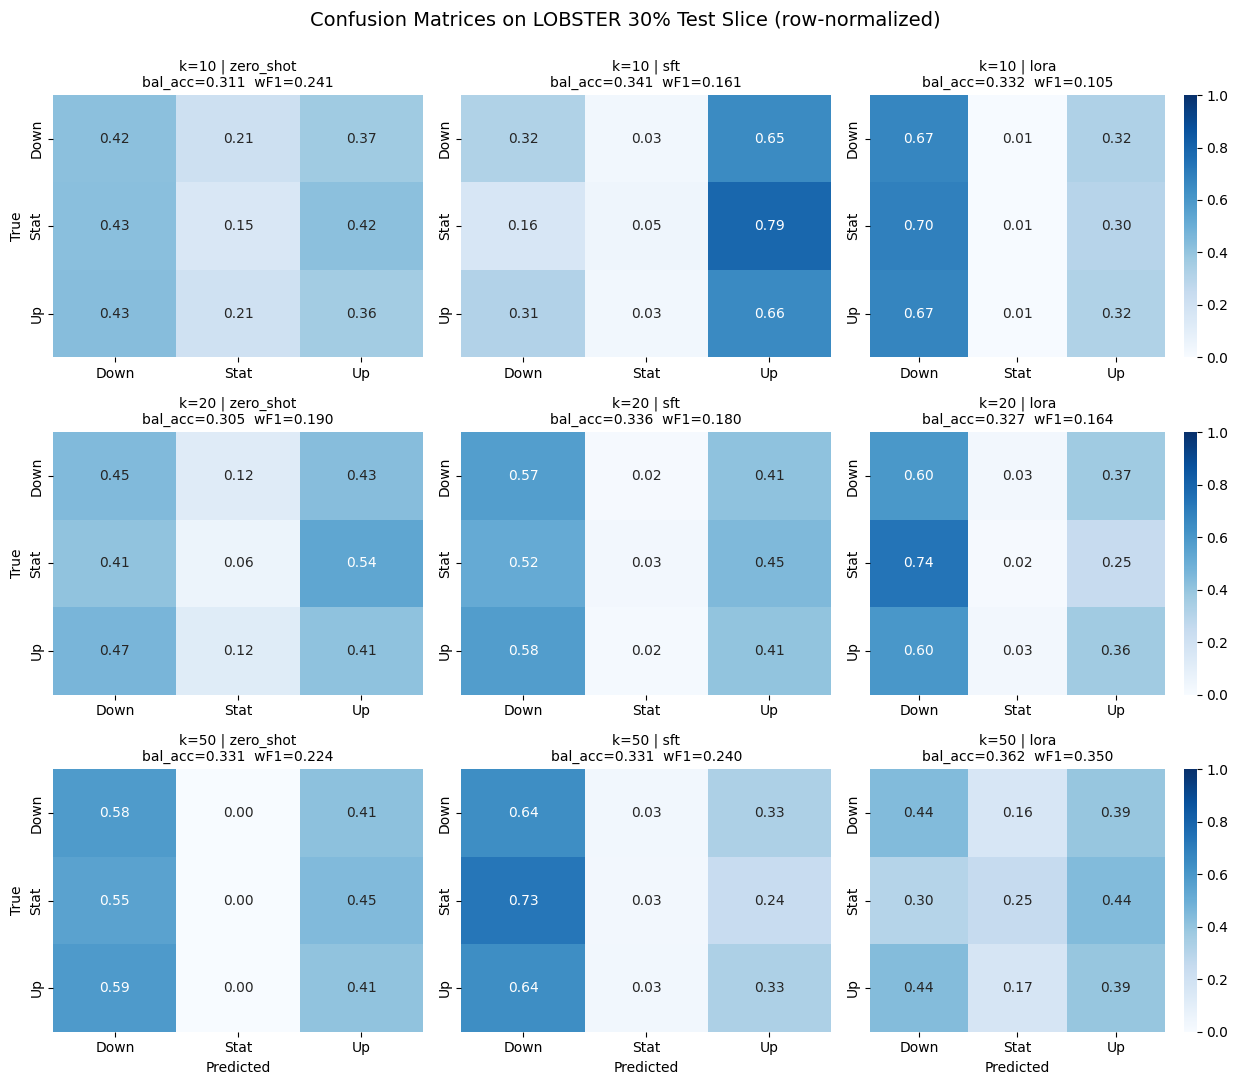

Saved → /content/drive/MyDrive/colab_data/lobs5_finetune_results/confusion_matrices_lobs5_finetune.png


In [16]:
fig, axes = plt.subplots(len(HORIZONS), len(METHODS),
                         figsize=(4.2 * len(METHODS), 3.6 * len(HORIZONS)),
                         squeeze=False)
fig.suptitle('Confusion Matrices on LOBSTER 30% Test Slice (row-normalized)', fontsize=14, y=1.00)

for i, k in enumerate(HORIZONS):
    for j, mode in enumerate(METHODS):
        ax = axes[i, j]
        rec = eval_records.get((k, mode))
        if rec is None:
            ax.set_title(f'k={k}, {mode}\n(missing)'); ax.axis('off'); continue
        cm = rec['confusion_matrix'].astype(np.float64)
        cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                    cbar=(j == len(METHODS) - 1), vmin=0, vmax=1, ax=ax)
        title = (f'k={k} | {mode}\n'
                 f'bal_acc={rec["balanced_acc"]:.3f}  '
                 f'wF1={rec["weighted_f1"]:.3f}')
        ax.set_title(title, fontsize=10)
        if i == len(HORIZONS) - 1: ax.set_xlabel('Predicted')
        else: ax.set_xlabel('')
        if j == 0: ax.set_ylabel('True')
        else: ax.set_ylabel('')

plt.tight_layout()
out_path = DRIVE_RESULTS_DIR / 'confusion_matrices_lobs5_finetune.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.savefig(LOCAL_RESULTS_DIR / out_path.name, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')


## 13. Metrics Summary

Aggregated table comparing all (horizon × method) cells. Reads naturally as: do the SFT and LoRA columns beat the `zero_shot` baseline at each horizon, and which mode wins where?

In [17]:
metric_cols = [
    'horizon', 'method',
    'balanced_acc', 'weighted_f1', 'macro_f1', 'cohen_kappa',
    'precision_down', 'precision_stat', 'precision_up',
    'recall_down',    'recall_stat',    'recall_up',
    'f1_down',        'f1_stat',        'f1_up',
]
rows = []
for (k, mode), rec in eval_records.items():
    rows.append({c: rec[c] for c in metric_cols})

df = pd.DataFrame(rows).sort_values(['horizon', 'method']).reset_index(drop=True)
csv_path = DRIVE_RESULTS_DIR / 'lobs5_finetune_metrics.csv'
df.to_csv(csv_path, index=False)
df.to_csv(LOCAL_RESULTS_DIR / csv_path.name, index=False)

# Pretty print
display_cols = ['horizon', 'method', 'balanced_acc', 'weighted_f1', 'macro_f1', 'cohen_kappa']
print('Headline metrics:')
print(df[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\nFull table saved → {csv_path}')


Headline metrics:
 horizon    method  balanced_acc  weighted_f1  macro_f1  cohen_kappa
      10      lora        0.3321       0.1052    0.1794      -0.0010
      10       sft        0.3407       0.1608    0.2155       0.0088
      10 zero_shot        0.3111       0.2406    0.2411      -0.0293
      20      lora        0.3268       0.1638    0.2197      -0.0089
      20       sft        0.3363       0.1795    0.2301       0.0053
      20 zero_shot        0.3053       0.1901    0.2282      -0.0387
      50      lora        0.3621       0.3497    0.3512       0.0456
      50       sft        0.3315       0.2404    0.2599      -0.0029
      50 zero_shot        0.3310       0.2244    0.2476      -0.0030

Full table saved → /content/drive/MyDrive/colab_data/lobs5_finetune_results/lobs5_finetune_metrics.csv


In [18]:
# Per-class precision/recall — useful for understanding which classes each
# method handles well, since LOB labels can be very imbalanced.
print('\nPer-class breakdown:')
pc_cols = ['horizon', 'method',
           'precision_down', 'recall_down', 'f1_down',
           'precision_stat', 'recall_stat', 'f1_stat',
           'precision_up',   'recall_up',   'f1_up']
print(df[pc_cols].to_string(index=False, float_format=lambda x: f'{x:.3f}'))



Per-class breakdown:
 horizon    method  precision_down  recall_down  f1_down  precision_stat  recall_stat  f1_stat  precision_up  recall_up  f1_up
      10      lora           0.181        0.671    0.285           0.601        0.006    0.012         0.193      0.319  0.241
      10       sft           0.268        0.317    0.290           0.726        0.049    0.092         0.165      0.656  0.264
      10 zero_shot           0.183        0.419    0.254           0.554        0.153    0.240         0.167      0.361  0.229
      20      lora           0.210        0.601    0.312           0.358        0.015    0.029         0.282      0.365  0.318
      20       sft           0.248        0.573    0.346           0.678        0.030    0.058         0.221      0.406  0.286
      20 zero_shot           0.245        0.446    0.316           0.346        0.057    0.098         0.201      0.412  0.270
      50      lora           0.348        0.444    0.390           0.498        0.252    

## 14. Bar Comparison

Side-by-side: balanced accuracy and weighted F1 by horizon × method. The interesting question is whether the SFT/LoRA bars rise above the `zero_shot` bar at each horizon.

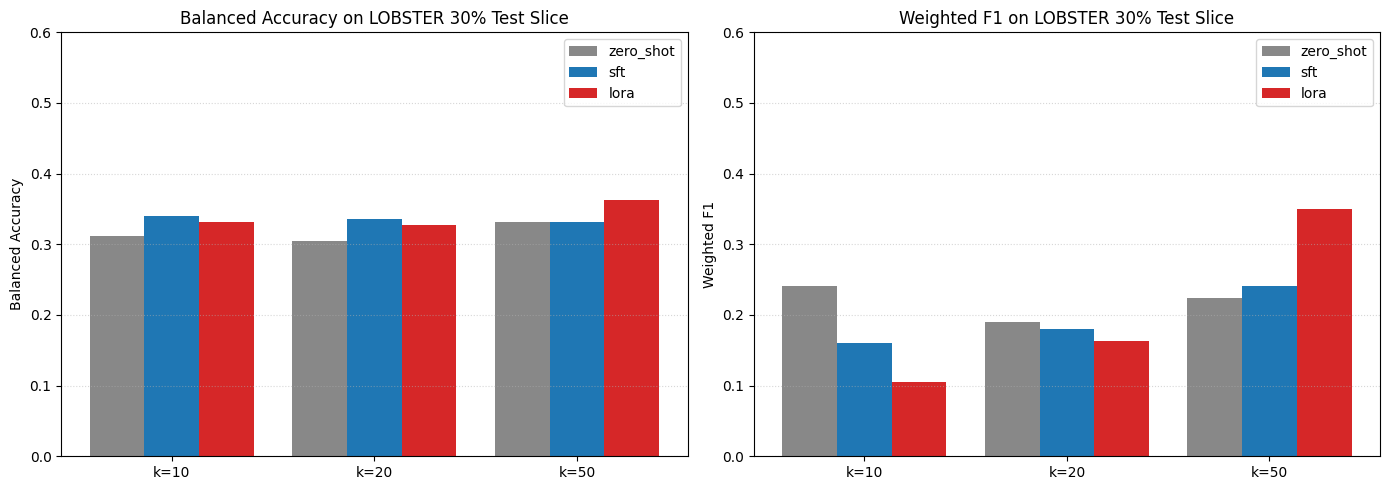

Saved → /content/drive/MyDrive/colab_data/lobs5_finetune_results/bar_comparison_lobs5_finetune.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

method_colors = {'zero_shot': '#888888', 'sft': '#1f77b4', 'lora': '#d62728'}
x = np.arange(len(HORIZONS))
bar_w = 0.27

for ax, metric, title in zip(
    axes, ['balanced_acc', 'weighted_f1'],
    ['Balanced Accuracy', 'Weighted F1'],
):
    for i, mode in enumerate(METHODS):
        vals = [eval_records.get((k, mode), {}).get(metric, np.nan) for k in HORIZONS]
        ax.bar(x + (i - 1) * bar_w, vals, bar_w, label=mode, color=method_colors[mode])
    ax.set_xticks(x); ax.set_xticklabels([f'k={k}' for k in HORIZONS])
    ax.set_ylabel(title); ax.set_title(f'{title} on LOBSTER 30% Test Slice')
    ax.set_ylim(0, max(0.6, ax.get_ylim()[1]))
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
out_path = DRIVE_RESULTS_DIR / 'bar_comparison_lobs5_finetune.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.savefig(LOCAL_RESULTS_DIR / out_path.name, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')


## 15. Final Summary

Compact print-out of the deltas vs the zero-shot baseline. Positive Δ ⇒ fine-tuning on synthetic LOBS5 helped; negative ⇒ it hurt.

In [20]:
print('=' * 78)
print(f'{"FI-2010 → LOBS5 → LOBSTER (zero-shot eval)":^78}')
print('=' * 78)
print(f'{"k":>4} {"method":>10} | {"bal_acc":>9} {"Δ":>7} | {"wF1":>7} {"Δ":>7} | {"κ":>7} {"Δ":>7}')
print('-' * 78)

for k in HORIZONS:
    base = eval_records.get((k, 'zero_shot'))
    if base is None:
        continue
    for mode in METHODS:
        rec = eval_records.get((k, mode))
        if rec is None: continue
        d_ba = rec['balanced_acc'] - base['balanced_acc']
        d_f1 = rec['weighted_f1']  - base['weighted_f1']
        d_k  = rec['cohen_kappa']  - base['cohen_kappa']
        if mode == 'zero_shot':
            print(f'{k:>4} {mode:>10} | '
                  f'{rec["balanced_acc"]:>9.4f} {"—":>7} | '
                  f'{rec["weighted_f1"]:>7.4f} {"—":>7} | '
                  f'{rec["cohen_kappa"]:>7.4f} {"—":>7}')
        else:
            print(f'{k:>4} {mode:>10} | '
                  f'{rec["balanced_acc"]:>9.4f} {d_ba:>+7.4f} | '
                  f'{rec["weighted_f1"]:>7.4f} {d_f1:>+7.4f} | '
                  f'{rec["cohen_kappa"]:>7.4f} {d_k:>+7.4f}')
    print('-' * 78)

print(f'\nArtifacts saved to: {DRIVE_RESULTS_DIR}')
print(f'  - lobs5_finetune_metrics.csv')
print(f'  - confusion_matrices_lobs5_finetune.png')
print(f'  - bar_comparison_lobs5_finetune.png')
print(f'\nCheckpoints saved to: {DRIVE_CKPT_DIR}')
for k in HORIZONS:
    for name in [sft_ckpt_name(k), lora_ckpt_name(k)]:
        p = DRIVE_CKPT_DIR / name
        flag = '✓' if p.exists() else '✗'
        print(f'  {flag} {name}')


                  FI-2010 → LOBS5 → LOBSTER (zero-shot eval)                  
   k     method |   bal_acc       Δ |     wF1       Δ |       κ       Δ
------------------------------------------------------------------------------
  10  zero_shot |    0.3111       — |  0.2406       — | -0.0293       —
  10        sft |    0.3407 +0.0296 |  0.1608 -0.0798 |  0.0088 +0.0381
  10       lora |    0.3321 +0.0209 |  0.1052 -0.1354 | -0.0010 +0.0283
------------------------------------------------------------------------------
  20  zero_shot |    0.3053       — |  0.1901       — | -0.0387       —
  20        sft |    0.3363 +0.0309 |  0.1795 -0.0105 |  0.0053 +0.0441
  20       lora |    0.3268 +0.0215 |  0.1638 -0.0263 | -0.0089 +0.0298
------------------------------------------------------------------------------
  50  zero_shot |    0.3310       — |  0.2244       — | -0.0030       —
  50        sft |    0.3315 +0.0004 |  0.2404 +0.0160 | -0.0029 +0.0002
  50       lora |    0.3621 +0.0310 